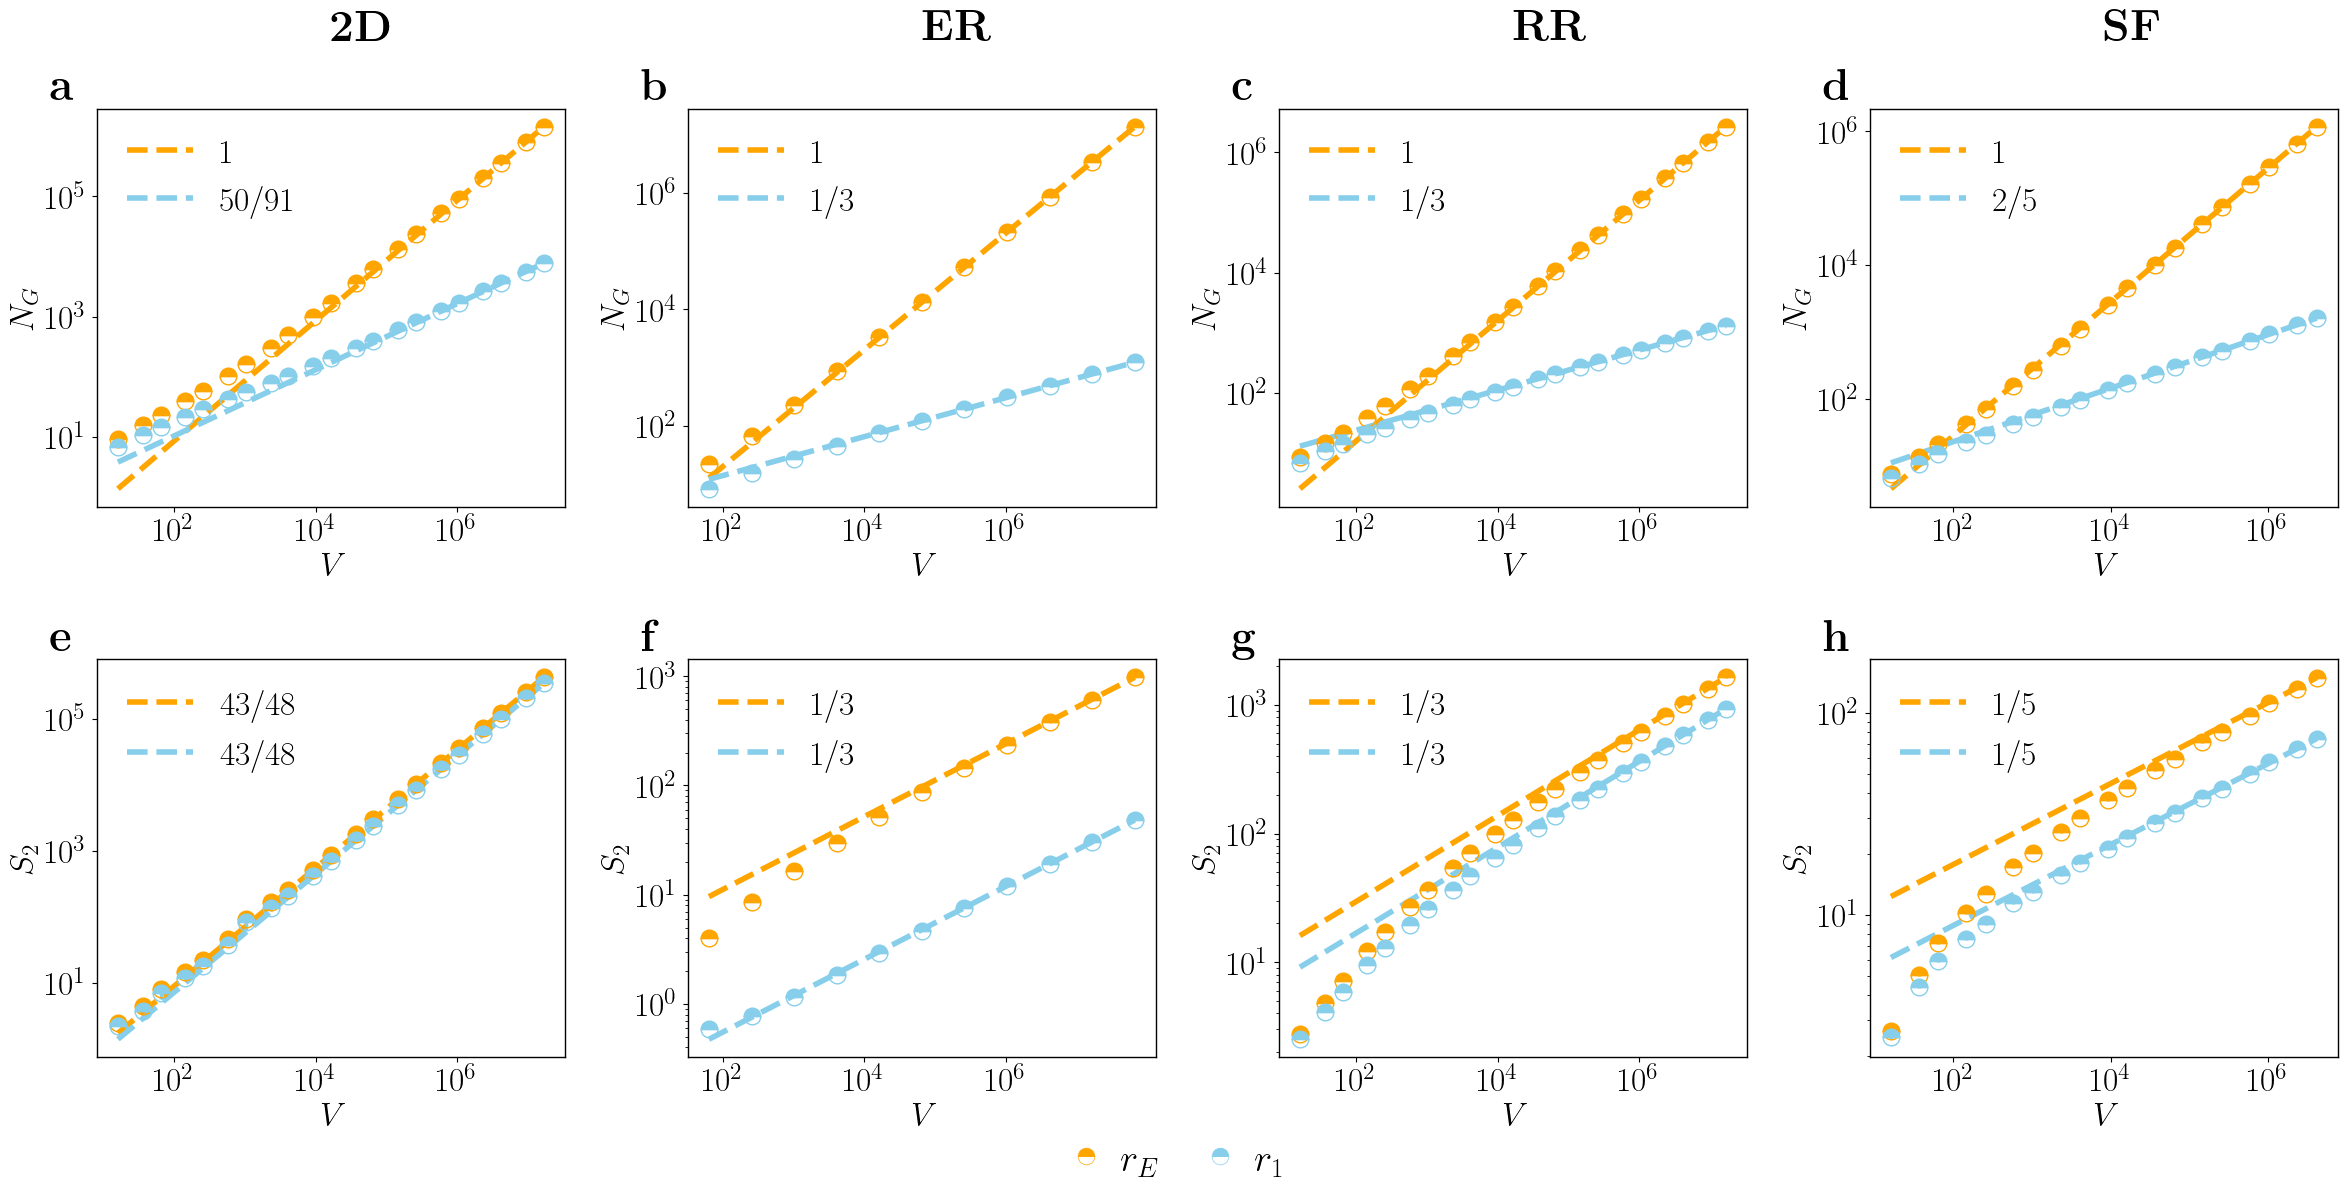

In [60]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
from matplotlib.lines import Line2D 

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 24,  # Nature typically uses smaller fonts
    'axes.labelsize': 24,  # Slightly larger for axis labels
    'axes.titlesize': 24,  # For panel labels
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
    'legend.fontsize': 24,
    'lines.linewidth': 2.5,
    'lines.markersize': 6,
    'axes.linewidth': 1.0,  # Thinner axes lines
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
})
mks = 12
lw1 = 4
figsizes = (24, 12)
LabelArr = ["$r_E$", "$r_1$"]
MarkerArr =['o', 'o']
ModelArr = ["2D", "ER", "RR", "SF"]
ObsArr   = ["NG", "S2G"]
QuanArr  = ['0', '1']
ColorArr = ['orange', 'skyblue']
YlabArr  = ["$N_G$", "$S_2$"]
Yh1Arr   =[50/91, 1/3, 1/3, 2/5]
Yh1sArr  =["50/91", "1/3", "1/3", "2/5"]
Yh2Arr   =[43/48, 1/3, 1/3, 1/5]
Yh2sArr  =["43/48", "1/3", "1/3", "1/5"]
fig, axes = plt.subplots(2, 4, figsize=figsizes)
for i, obs in enumerate(ObsArr):
    for j, model in enumerate(ModelArr):
        ax = axes[i, j]
        for k, quan in enumerate(QuanArr):
            f1 = model + obs + quan
            data = np.loadtxt(f1, usecols=(0, 1, 2))
            x = data[:, 0]**2
            y = data[:, 1]
            yerr = data[:, 2]
            if i==1:
                y = y*x
                yerr = yerr*x
            if i ==0:
                ax.errorbar(x, y, yerr=yerr, color=ColorArr[k], fillstyle='top', fmt='o', markersize=mks)
                if k==1:
                    a0 = y[-1]/x[-1]**Yh1Arr[j] 
                    ax.plot(x, a0*x**Yh1Arr[j], color=ColorArr[k], linestyle='--', lw = lw1, label=f"{Yh1sArr[j]}")
                else:
                    a0 = y[-1]/x[-1]
                    ax.plot(x, a0*x, color=ColorArr[k], linestyle='--', lw = lw1,  label="1")
                    
            else:
                ax.errorbar(x, y, yerr=yerr, color=ColorArr[k], fillstyle='top', fmt='o', markersize=mks)
#                if k==0:
                a0 = y[-1]/x[-1]**Yh2Arr[j] 
                ax.plot(x, a0*x**Yh2Arr[j], color=ColorArr[k], linestyle='--', lw=lw1, label=f"{Yh2sArr[j]}")
        ax.set_xlabel('$V$')
        ax.set_ylabel(YlabArr[i])
        ax.set_xscale("log") 
        ax.set_yscale("log") 
        ax.set_xticks([1e2, 1e4, 1e6])
#        ax.set_yticks([1e1, 1e3, 1e5])
        kla = i*4 + j
        ax.text(-0.10, 1.10,r'$\mathbf{' + chr(97+kla) +'}$', transform=ax.transAxes, fontsize=32, 
            fontweight='bold', verticalalignment='top', horizontalalignment='left')
        if i ==0:
            ax.text(0.50, 1.25,  r'$\mathbf{' + ModelArr[j] +'}$', transform=ax.transAxes, fontsize=32, 
                fontweight='bold', verticalalignment='top', horizontalalignment='left')

        ax.legend(loc='upper left', frameon=False)

# 创建图例元素（用于上部子图）
legend_elements = [Line2D([0], [0], marker=MarkerArr[k], color=ColorArr[k], 
                   markerfacecolor=ColorArr[k], markersize=12,
                   fillstyle='top', markeredgewidth=0.5, markeredgecolor=ColorArr[k], 
                   linestyle='None', label=LabelArr[k]) for k in range(2)]

# 将图例放在上部区域的顶部中央，调小距离
fig.legend(handles=legend_elements,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.05),  # 从0.98改为0.99，减小距离
           ncol=2,
           fontsize=28,
           frameon=False,
           fancybox=True,
           shadow=False,
           handletextpad=0.3,
           columnspacing=1.0,
           handlelength=1.2)

plt.tight_layout()
plt.savefig("FigS5.pdf")
plt.show()